# **i. Introduction**

Name: Yocia Meiko Oke

Batch: RMT-036

Dataset: [Insurance Dataset](https://raw.githubusercontent.com/FTDS-learning-materials/datasets/main/insurance.csv)

**SMART**  
- Specific: Focus on predicting the estimated health insurance premium cost to choose the most cost-effective plan based on my current needs.

- Measurable: Aim to reduce health-related expenses by at least 20-25% compared to not having insurance, by selecting the best insurance option.

- Achievable: Create a Machine Learning model to predict the cost of health insurance premiums and choose a plan that aligns with my medical needs and financial situation.

- Relevant: Reducing long-term health costs is critical for financial stability, especially with high medical expenses in the U.S.

- Time-bound: Apply for a health insurance plan by the end of next month.

**Problem Statement:**  
With the high cost of medical care in the U.S., having health insurance is essential to manage long-term health expenses. The goal is to reduce health related costs by 20-25% in the long run by selecting the most appropriate and cost-effective insurance by implementing a machine learning model to predict the estimated annual premium for health insurance. I plan to apply for health insurance by the end of next month.

**Objective:**  
To develop a predictive model that estimates the health insurance premium cost based on individual factors (e.g., age, sex, bmi, children, etc.). This will help in selecting the most suitable insurance plan that minimizes health expenses compared to not having insurance.

# **ii. Import Libraries**

>Importing all libraries needed in the project

First we will import all libraries and modules that we are going to use in this project.

In [178]:
# Import libraries

import pandas as pd # for data manipulation & analysis
import numpy as np # for numerical computations
import matplotlib.pyplot as plt # for visualizations
import seaborn as sns # for advanced visualizations
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# **iii. Data Loading**

> Loading the dataset, check the dataset, and check duplicates.

Next, we will load the data for further exploration.

In [179]:
# Load dataset
df_ori = pd.read_csv("https://raw.githubusercontent.com/FTDS-learning-materials/datasets/main/insurance.csv")

# Create a new dataset variable and copy the data for exploration using .copy()
df = df_ori.copy()

df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [180]:
# Check dataset using .info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


There are 3 columns of `object` type:
- `sex`: gender of beneficiary (female or male)
- `smoker`: smoker or not smoker (yer or no)
- `region`: residential of beneficiary in the U.S.

2 columns of `integer` type:
- `age`: age of beneficiary
- `children`: the number of dependents (children)

2 columns of `float` type:
- `bmi`: body mass index
- `charges`: individual medical costs

The dataset has the correct data types for each corresponding column, so we do not need to change any of the column's data types.

The columns will be categorized as:
- Numerical column =['age', 'children', 'bmi', 'chages'] # Continuous or discrete numerical values
- Categorical nominal = ['sex', 'smoker', 'region'] # No inherent order/rankings
- Categorical encoded = None 
- Categorical ordinal = None # Inherent order/rankings

As of now, there are no encoded categorical columns, but we may need to encode the sex, smoker, or even region columns for modeling purposes.

In [181]:
# Check dataset using .describe()
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Based on the data above, we can observe the following:

- The average age of individuals in the dataset is 39 years, with the oldest being 64 and the youngest 18.

- The average BMI of individuals enrolled in insurance is 30.66 (obesed), with a minimum of 15.96 (underweight) and a maximum of 53(extremely obesed). Below are the BMI categories:

    **BMI	Weight Status**  
    Below 18.5	  : Underweight  
    18.5—24.9	  : Healthy Weight  
    25.0—29.9	  : Overweight  
    30.0 and Above:	Obesity  

- The average number of children is 1. While some people have no children, others have up to 5 children.

- The average medical charges are $13,270, with the lowest being $1,121 and the highest $63,770.

## Check Duplicates

In [182]:
# Check duplicates
df.duplicated().sum()

1

In [183]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [184]:
# Re-check after dropping duplicates
df.duplicated().sum()

0

# **iv. Exploratory Data Analysis (EDA)**

> This part will cover data exploration using query, grouping, visualization, etc. to understand the data better.



**AGE**

For age, since it is continuous numerical data, we can use either Histogram or BoxPlot.

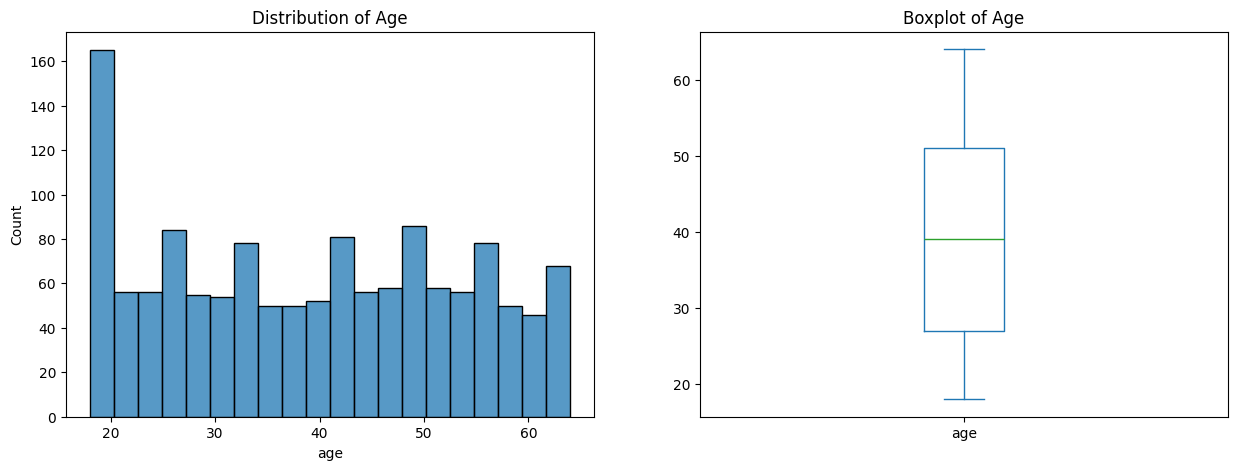

In [185]:
# Create canvas
plt.figure(figsize=(15,5))

# Histogram for 'age' column with seaborn
plt.subplot(1,2,1)
sns.histplot(df.age,bins=20)
plt.title('Distribution of Age')

# BoxPlot for 'age' column with pandas
plt.subplot(1,2,2)
df['age'].plot(kind='box')
plt.title('Boxplot of Age')

# Show
plt.show()

**SEX**

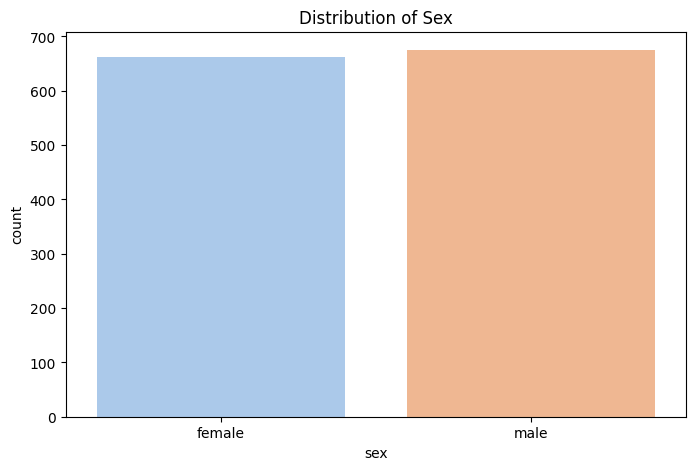

In [186]:
# Create canvas
plt.figure(figsize=(8,5))

# Countplot for 'sex' column with seaborn
sns.countplot(data=df, x='sex', palette='pastel', hue=df.sex)
plt.title('Distribution of Sex')

# Show
plt.show()

**BMI**

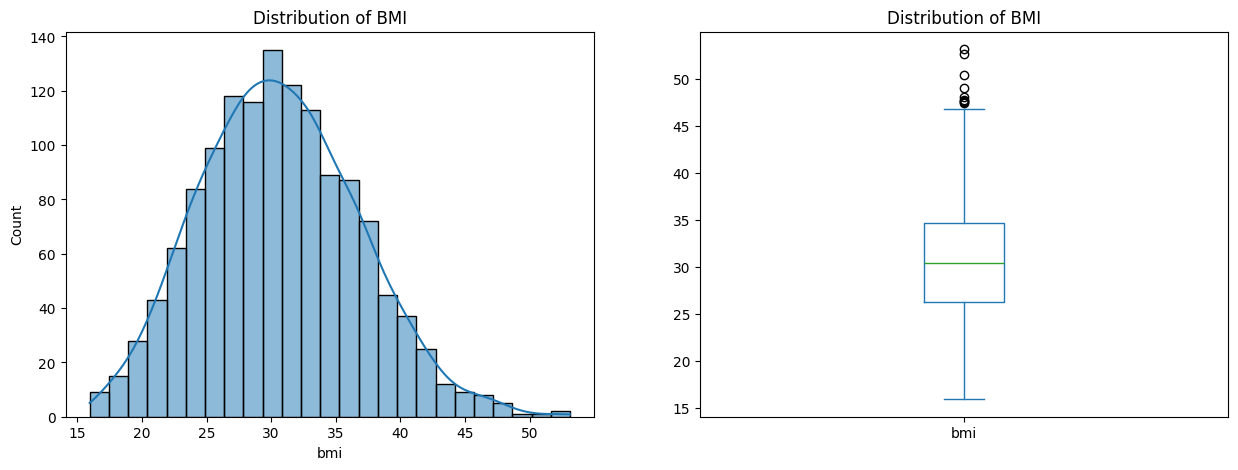

In [187]:
# Create canvas
plt.figure(figsize=(15,5))

# Histogram for 'bmi' column with seaborn
plt.subplot(1,2,1)
sns.histplot(df.bmi, kde=True,bins=25)
plt.title('Distribution of BMI')

# Boxplot for 'bmi' column with pandas
plt.subplot(1,2,2)
df['bmi'].plot(kind='box')
plt.title('Distribution of BMI')

# Show
plt.show()

**CHILDREN**

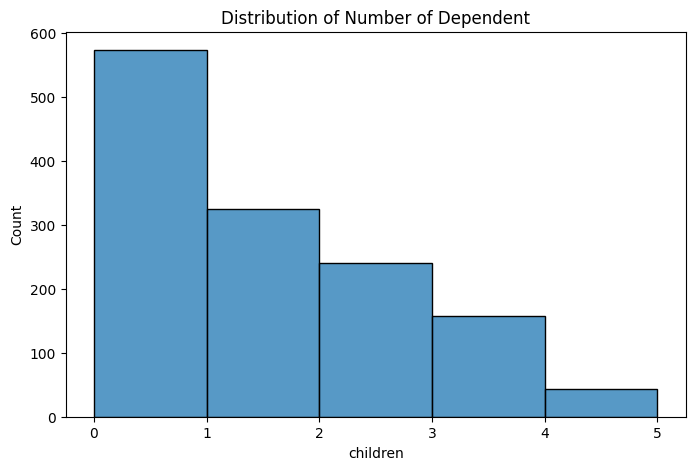

In [188]:
# Create canvas
plt.figure(figsize=(8,5))

# Histogram for 'children' column with seaborn
sns.histplot(df.children,bins=5)
plt.title('Distribution of Number of Dependent')

# Show
plt.show()

**SMOKER**

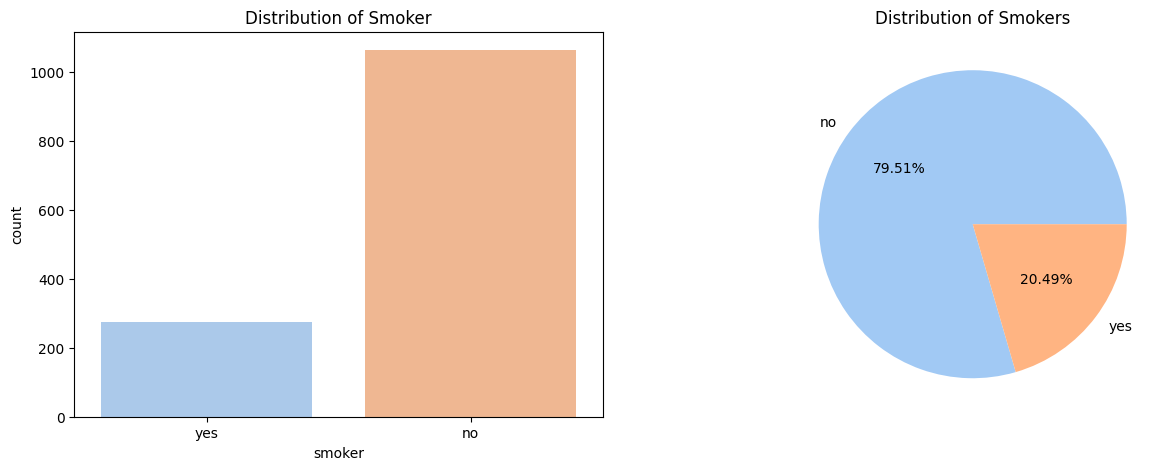

In [189]:
# Create canvas
plt.figure(figsize=(15,5))

# Countplot for 'sex' column with seaborn
plt.subplot(1,2,1)
sns.countplot(x=df.smoker, palette='pastel', hue=df.smoker)
plt.title('Distribution of Smoker')

# Pie Chart for 'sex' column with seaborn
plt.subplot(1,2,2)
smoker_counts = df['smoker'].value_counts()  # Get counts of smoker vs non-smoker
pastel_colors = sns.color_palette('pastel')
smoker_counts.plot.pie(autopct='%1.2f%%', colors=pastel_colors)
plt.title('Distribution of Smokers')
plt.ylabel("")

# Show
plt.show()

**REGION**

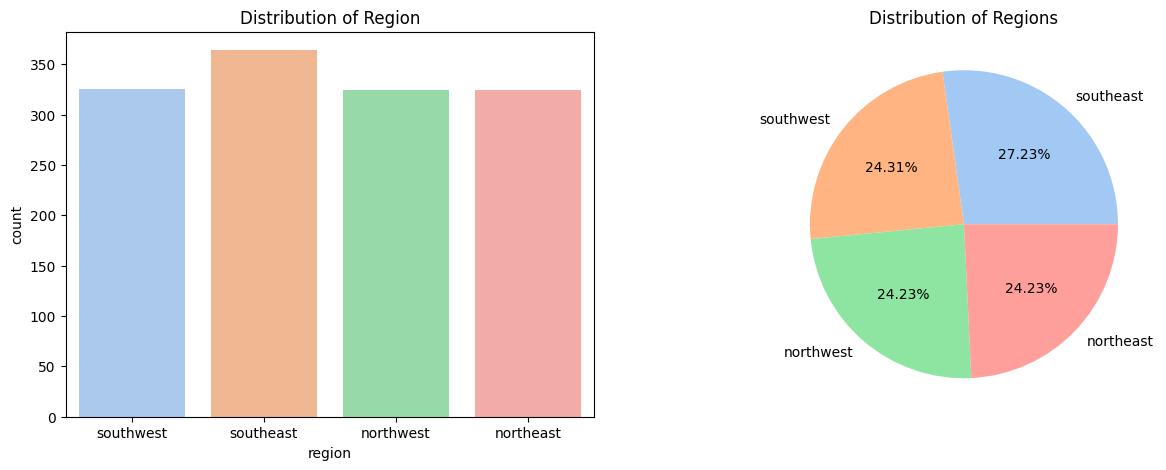

In [190]:
# Create canvas
plt.figure(figsize=(15,5))

# Countplot for 'region' column with seaborn
plt.subplot(1,2,1)
sns.countplot(x=df.region, palette='pastel', hue=df.region)
plt.title('Distribution of Region')

# Pie Chart for 'region' column with seaborn
plt.subplot(1,2,2)
region_counts = df['region'].value_counts()
pastel_colors = sns.color_palette('pastel')
region_counts.plot.pie(autopct='%1.2f%%', colors=pastel_colors)
plt.title('Distribution of Regions')
plt.ylabel("")

# Show
plt.show()

**CHARGES**

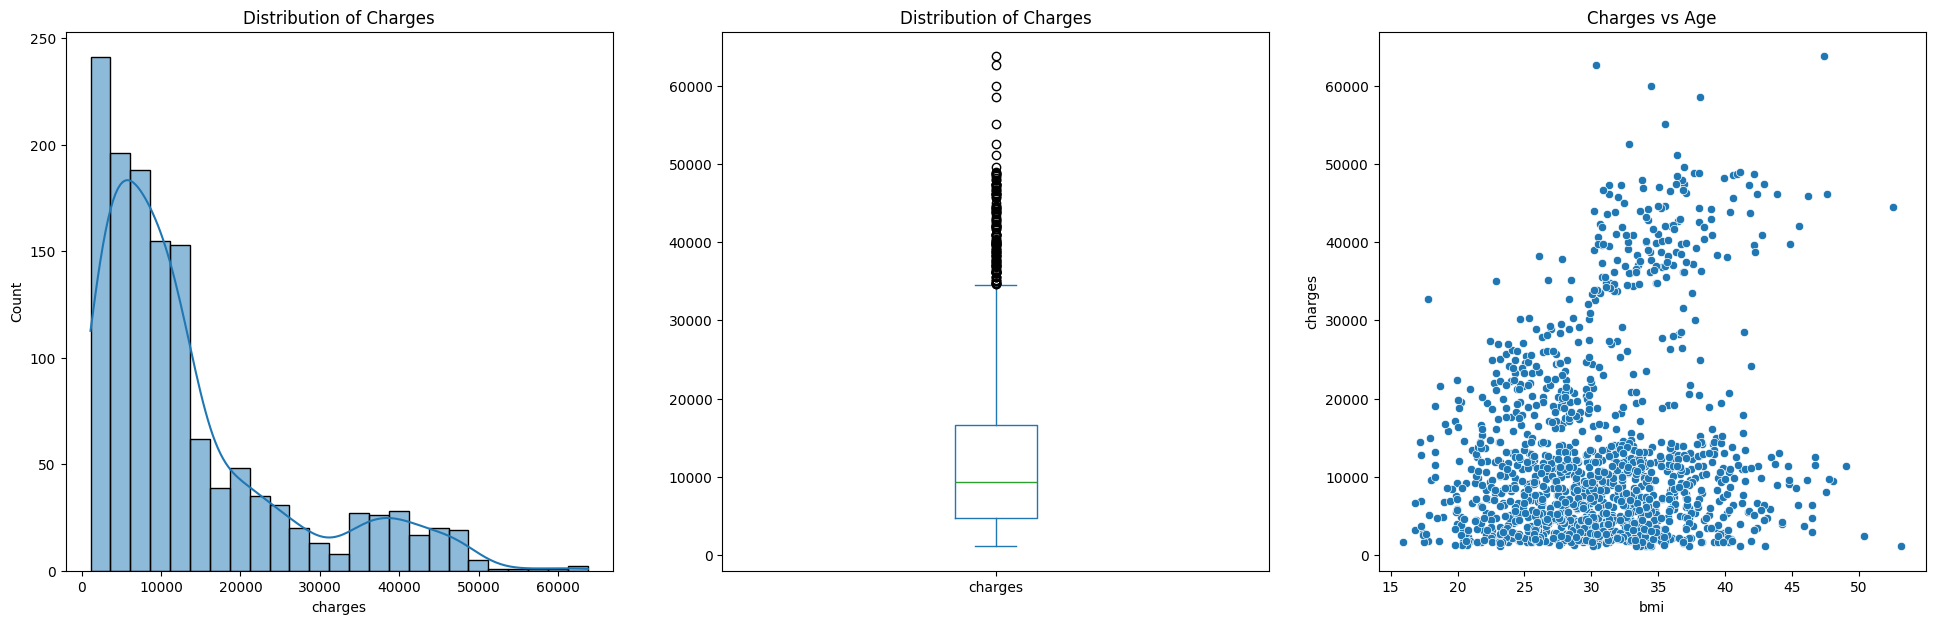

In [191]:
# Create canvas
plt.figure(figsize=(24,7))

# Histogram for 'charges' column with seaborn
plt.subplot(1,3,1)
sns.histplot(df.charges, kde=True, bins=25)
plt.title('Distribution of Charges')

# Boxplot for 'charges' column with pandas
plt.subplot(1,3,2)
df['charges'].plot(kind='box')
plt.title('Distribution of Charges')

# Scatterplot for 'charges' column with seaborn
plt.subplot(1,3,3)
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title('Charges vs Age')

# Show
plt.show()

# **v. Feature Engineering**

>We will now prepare the data for model training. This includes tasks such as splitting the data into training and test sets, applying data transformations (e.g., normalization, encoding), and other necessary processes.

## Split X (features) and y (target)

In [192]:
# Split between x and y
X = df.drop(['charges'], axis=1)
y = df.charges

In [193]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [194]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

## Split between Train and Test

In [195]:
# Splitting between train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=107)

print('train size:', X_train.shape)
print('test size:', X_test.shape)
print(X_train)

train size: (1069, 6)
test size: (268, 6)
      age     sex     bmi  children smoker     region
410    19    male  17.480         0     no  northwest
1329   52    male  38.600         2     no  southwest
175    63  female  37.700         0    yes  southwest
1147   20  female  31.920         0     no  northwest
650    49  female  42.680         2     no  southeast
...   ...     ...     ...       ...    ...        ...
655    52  female  25.300         2    yes  southeast
454    32    male  46.530         2     no  southeast
473    47  female  33.345         0     no  northeast
1201   46    male  40.375         2     no  northwest
62     64    male  24.700         1     no  northwest

[1069 rows x 6 columns]


## Handling Outlier

> TBD

## Check Missing Value

Standard missing values `NaN` or `None`

In [196]:
# Check total missing values per column
X_train_missing_values = X_train.isnull().sum()
print("X_train_missing_values")
print(X_train_missing_values)

print("")

X_test_missing_values = X_test.isnull().sum()
print("X_test_missing_values")
print(X_test_missing_values)

print("")

y_train_missing_values = y_train.isnull().sum()
print("y_train_missing_values")
print(y_train_missing_values)

print("")

y_test_missing_values = y_test.isnull().sum()
print("y_test_missing_values")
print(y_test_missing_values)

X_train_missing_values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64

X_test_missing_values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64

y_train_missing_values
0

y_test_missing_values
0


Non-standard missing : 'N/A', '-', 'Unknown', 'None', etc.

In [197]:
for Xtrain_column in X_train.columns:
    print(f"Unique values in {Xtrain_column}:")
    print(X_train[Xtrain_column].unique())

print("")

for Xtest_column in X_test.columns:
    print(f"Unique values in {Xtest_column}:")
    print(X_test[Xtest_column].unique())

print("")

print(f"Unique values in y_train:")
print(y_train.unique())

print("")

print(f"Unique values in y_test:")
print(y_test.unique())

Unique values in age:
[19 52 63 20 49 44 45 37 29 18 30 28 40 39 23 22 56 25 24 34 41 62 38 48
 60 21 50 54 26 27 46 64 53 57 61 32 43 58 59 35 31 47 51 33 55 42 36]
Unique values in sex:
['male' 'female']
Unique values in bmi:
[17.48  38.6   37.7   31.92  42.68  39.52  25.175 24.32  25.6   31.35
 27.7   28.88  25.08  32.5   32.775 50.38  29.735 36.    27.2   41.325
 29.83  26.73  21.66  23.465 33.3   21.85  22.895 29.59  33.99  33.55
 31.79  39.16  37.07  23.845 33.66  37.05  32.3   25.74  25.7   26.22
 25.46  27.5   33.82  34.2   46.53  17.955 29.81  27.36  20.52  27.72
 23.085 28.12  31.825 22.135 22.61  29.64  32.11  38.28  23.98  26.695
 33.8   36.86  35.53  31.54  34.8   22.3   39.9   31.73  33.44  21.47
 34.77  35.91  36.63  34.1   31.1   27.645 39.27  15.96  33.63  31.57
 22.515 40.26  29.8   35.625 30.25  34.4   27.74  41.8   38.19  28.82
 26.6   25.745 29.9   32.67  38.17  33.    37.29  29.    28.405 29.7
 34.32  30.2   33.345 27.83  24.31  28.4   23.75  36.765 26.62  23.21
 

Based on the data above, we can see that there is no any nulll values.
When we check the unique values, every value seems proper.

## Feature Selection

## Cardinality Test

### Split between numerical and categorical columns, for scaling and encoding

In [198]:
# Manual split
num_col = ['age', 'bmi', 'children']
cat_col = ['sex','smoker','region']

print(f'numerical : {num_col}')
print(f'categorical : {cat_col}')

numerical : ['age', 'bmi', 'children']
categorical : ['sex', 'smoker', 'region']


In [199]:
X_train_num = X_train[num_col]
X_test_num = X_test[num_col]
X_train_cat = X_train[cat_col]
X_test_cat = X_test[cat_col]

## Feature Scaling

In [200]:
X_train.describe()

,age,bmi,children
count,1069.000000,1069.000000,1069.000000
mean,39.161833,30.484892,1.084191
std,14.081458,6.081928,1.204091
min,18.000000,15.960000,0.000000
25%,26.000000,26.125000,0.000000
50%,39.000000,30.200000,1.000000
75%,51.000000,34.430000,2.000000
max,64.000000,52.580000,5.000000


In [201]:
# Define scaling method
scaler = MinMaxScaler()

# .fit
scaler.fit(X_train_num)

# . transform
X_train_num_scaled = scaler.transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

In [202]:
X_train_num_scaled

array([[0.02173913, 0.04150737, 0.        ],
       [0.73913043, 0.6182414 , 0.4       ],
       [0.97826087, 0.59366466, 0.        ],
       ...,
       [0.63043478, 0.47474058, 0.        ],
       [0.60869565, 0.66671218, 0.4       ],
       [1.        , 0.23866739, 0.2       ]])

In [203]:
# Cek unique value from sex
X_train_cat.sex.unique()

array(['male', 'female'], dtype=object)

In [204]:
# Cek unique value from smoker
X_train_cat.smoker.unique()

array(['no', 'yes'], dtype=object)

In [205]:
# Cek unique value from region
X_train_cat.region.unique()

array(['northwest', 'southwest', 'southeast', 'northeast'], dtype=object)

In [206]:
# Cek urutan kolom, attack duluan atau defense duluan
X_train_cat.head()

,sex,smoker,region
410,male,no,northwest
1329,male,no,southwest
175,female,yes,southwest
1147,female,no,northwest
650,female,no,southeast


In [215]:
encoder = OneHotEncoder(categories=[['male','female'], #u/ col 1
                                    ['no','yes'], #u/ col 2
                                    ['northwest', 'southwest', 'southeast', 'northeast'] #u/ col 3
                                    ])
encoder.fit(X_train_cat)
X_train_cat_encoded = encoder.transform(X_train_cat).toarray()
X_test_cat_encoded = encoder.transform(X_test_cat).toarray()

In [216]:
X_train_cat_encoded

array([[1., 0., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 1.],
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.]])

## Concating between Numerical and Categorical

In [217]:
# Concat
X_train_final = np.concatenate([X_train_cat_encoded,X_train_num_scaled], axis=1)
X_test_final = np.concatenate([X_test_cat_encoded,X_test_num_scaled], axis=1)

# **vi. Model Definition**

In [218]:
# Define model
model_lin = LinearRegression()

# **vii. Model Training**

In [219]:
# Train the model
model_lin.fit(X_train_final,y_train)

LinearRegression()

# **viii. Model Evaluation**

In [220]:
# Predict Train and test

y_pred_train = model_lin.predict(X_train_final)
y_pred_test = model_lin.predict(X_test_final)

print(y_pred_train)

[-1664. 14400. 38912. ... 11904. 14080. 12672.]


In [221]:
y_train

410      1621.34020
1329    10325.20600
175     48824.45000
1147     2261.56880
650      9800.88820
           ...     
655     24667.41900
454      4686.38870
473     20878.78443
1201     8733.22925
62      30166.61817
Name: charges, Length: 1069, dtype: float64

In [222]:
# Evaluate the model
print('Error - train:', mean_absolute_error(y_train, y_pred_train))
print('Error - test:', mean_absolute_error(y_test, y_pred_test))

Error - train: 4288.907452666043
Error - test: 4272.707490294776


# **ix. Model Saving for Inference**

# **x. Conclusion**